# 최적화 알고리즘 비교

In [110]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

In [111]:
print("GPU 사용 가능 여부:", torch.cuda.is_available())
print("사용 가능한 GPU 개수:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("현재 GPU 이름:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU 사용 가능 여부: True
사용 가능한 GPU 개수: 1
현재 GPU 이름: NVIDIA GeForce RTX 4070 Ti


In [112]:
# 추천된 데이터 셋에 대한 정보 출력
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',       
    train=True,          
    download=True,       
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_counts = torch.bincount(train_dataset.targets)
test_counts = torch.bincount(test_dataset.targets)

# 정보 사열 
print("학습 데이터셋 크기:", len(train_dataset))
print("테스트 데이터셋 크기:", len(test_dataset))
print("\n")
print("학습 데이터셋 이미지 크기:", train_dataset[0][0].shape)
print("테스트 데이터셋 이미지 크기:", test_dataset[0][0].shape)
print("\n")
print("학습 데이터셋 클래스 이름:", train_dataset.classes)
print("테스트 데이터셋 클래스 이름:", test_dataset.classes)
print("\n")
print("학습 데이터셋 클래스별 데이터 수:", {cls: train_counts[idx].item() for idx, cls in enumerate(train_dataset.classes)})
print("테스트 데이터셋 클래스별 데이터 수:", {cls: test_counts[idx].item() for idx, cls in enumerate(test_dataset.classes)})

학습 데이터셋 크기: 60000
테스트 데이터셋 크기: 10000


학습 데이터셋 이미지 크기: torch.Size([1, 28, 28])
테스트 데이터셋 이미지 크기: torch.Size([1, 28, 28])


학습 데이터셋 클래스 이름: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
테스트 데이터셋 클래스 이름: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


학습 데이터셋 클래스별 데이터 수: {'T-shirt/top': 6000, 'Trouser': 6000, 'Pullover': 6000, 'Dress': 6000, 'Coat': 6000, 'Sandal': 6000, 'Shirt': 6000, 'Sneaker': 6000, 'Bag': 6000, 'Ankle boot': 6000}
테스트 데이터셋 클래스별 데이터 수: {'T-shirt/top': 1000, 'Trouser': 1000, 'Pullover': 1000, 'Dress': 1000, 'Coat': 1000, 'Sandal': 1000, 'Shirt': 1000, 'Sneaker': 1000, 'Bag': 1000, 'Ankle boot': 1000}


# 모델들

In [113]:
class BaselineNet(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(BaselineNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = x.view(x.size(0), -1) 
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        logits = self.fc3(x)
        return logits
    
class ShallowNet(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(ShallowNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        logits = self.fc3(x)
        return logits
    
class DeepNet(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(DeepNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        logits = self.fc4(x)
        return logits

# 하이퍼 파라미터

In [114]:
config = {
    "model_type": "BaselineNet",      # "ShallowNet", "BaselineNet", "DeepNet"
    "epochs": 30,                     
    "batch_size": 64,                 # 배치 크기
    "learning_rate": 0.001,           # 학습률 
    "loss_type": "CE",                
    
    "optimizer_type": "Adam",         # "SGD", "Momentum", "Adam"
    "momentum": 0.9,
}

In [115]:
# config = {
#     "model_type": "BaselineNet",      # "ShallowNet", "BaselineNet", "DeepNet"
#     "epochs": 30,                     
#     "batch_size": 64,                 # 배치 크기
#     "learning_rate": 0.01,           # 학습률 
#     "loss_type": "CE",                
    
#     "optimizer_type": "Momentum",         # "SGD", "Momentum", "Adam"
#     "momentum": 0.9,
# }

In [116]:
# config = {
#     "model_type": "BaselineNet",      # "ShallowNet", "BaselineNet", "DeepNet"
#     "epochs": 20,                     
#     "batch_size": 64,                 # 배치 크기
#     "learning_rate": 0.001,           # 학습률 
#     "loss_type": "CE",                
    
#     "optimizer_type": "Adam",         # "SGD", "Momentum", "Adam"
#     "momentum": 0.9,
# }

# 결과 저장소

In [117]:
results = {
    "config": config.copy(),

    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    
    "final_accuracy": 0.0,            # 최종 테스트 정확도
    "converged_epoch": 0,             # Loss 최솟값에 도달한 에폭 번호
    "stability_score": "",            
    "stability_std": 0.0,             
    
    "logits_distribution": {          # 출력층 직전 Logits 값 추적 (히스토그램용)
        "1": None,               
        "5": None,                  
        "10": None,
        "15": None,
        "20": None,
        "25": None,
        "30": None,


    },
    "gradient_flow": {                
        "early": {},                  
        "mid": {},
        "late": {}
    },

    
}

# 사전 준비

In [118]:
def to_one_hot(labels, num_classes=10):
    return torch.eye(num_classes, device=labels.device)[labels]

In [ ]:
epochs = config["epochs"]
loss_type = config["loss_type"]
lr = config["learning_rate"]
batch_size = config["batch_size"]
opt_type = results["config"]["optimizer_type"]



if config["model_type"] == "BaselineNet":
    model = BaselineNet().to(device)
elif config["model_type"] == "ShallowNet":
    model = ShallowNet().to(device)  
elif config["model_type"] == "DeepNet":
    model = DeepNet().to(device)    

if config["optimizer_type"] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=lr)
elif config["optimizer_type"] == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=lr)    
elif config["optimizer_type"] == "Momentum":
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=config["momentum"])

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)


best_val_loss = float('inf') 




# 지수 감소 스캐쥴러
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
# stap decay 스케쥴러
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)
# Cosine Annealing (코사인 감소)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
# ReduceLROnPlateau (검증 손실이 개선되지 않으면 학습률 감소)
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

In [120]:


for epoch in range(1, epochs + 1):
    
    # --- [TRAIN LOOP] ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    epoch_first_logits = None
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(inputs)

        if batch_idx == 0:
            epoch_first_logits = logits.detach().cpu().numpy()
        
        if loss_type == "CE":
            criterion = nn.CrossEntropyLoss()
            loss = criterion(logits, labels)
        elif loss_type == "MSE":
            criterion = nn.MSELoss()
            outputs = torch.softmax(logits, dim=1)
            target_one_hot = to_one_hot(labels, num_classes=10)
            loss = criterion(outputs, target_one_hot)
            
        loss.backward()
        
        
        if batch_idx == 0 and epoch in [1, 8, 14]:
            period = "early" if epoch == 1 else "mid" if epoch == 8 else "late"
            
            for name, param in model.named_parameters():        # 모델 내부 가중치 레이어들을 돌며 gradient 평균값 추출
                if param.grad is not None and "weight" in name:
                    results["gradient_flow"][period][name] = param.grad.abs().mean().item()





        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(logits, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100

    # --- [TEST LOOP] ---
    model.eval()
    test_loss, correct_test, total_test = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            
            if loss_type == "CE":
                criterion = nn.CrossEntropyLoss()
                loss = criterion(logits, labels)
            elif loss_type == "MSE":
                criterion = nn.MSELoss()
                outputs = torch.softmax(logits, dim=1)
                target_one_hot = to_one_hot(labels, num_classes=10)
                loss = criterion(outputs, target_one_hot)
                
            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(logits, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    epoch_test_loss = test_loss / total_test
    epoch_test_acc = (correct_test / total_test) * 100
    
    # --- [results] ---
    results["train_loss"].append(epoch_train_loss)
    results["train_acc"].append(epoch_train_acc)
    results["val_loss"].append(epoch_test_loss)
    results["val_acc"].append(epoch_test_acc)
    
    # 수렴 에폭(Loss 최솟값 도달 시점) 업데이트
    if epoch_test_loss < best_val_loss:
        best_val_loss = epoch_test_loss
        results["converged_epoch"] = epoch
        
    # 초/중/후반 로지트 분포 복사본 저장
    if epoch == 1:
        results["logits_distribution"]["early"] = epoch_first_logits
    elif epoch == 8:
        results["logits_distribution"]["mid"] = epoch_first_logits
    elif epoch == 14:
        results["logits_distribution"]["late"] = epoch_first_logits



    scheduler.step()

    print(f"Epoch [{epoch:02d}/{epochs:02d}] Train Loss: {epoch_train_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")

# 최종 정확도 저장
results["final_accuracy"] = results["val_acc"][-1]


val_losses = results["val_loss"]
if len(val_losses) > 1:

    loss_diffs = np.diff(val_losses)
    stability_val = float(np.std(loss_diffs))
    results["stability_std"] = stability_val

    if stability_val > 0.05 or (val_losses[-1] - min(val_losses) > 0.1):
        results["stability_score"] = "불안정 (Overshooting)"
    elif stability_val < 0.001 and results["converged_epoch"] > (config["epochs"] * 0.8):
        results["stability_score"] = "정체 (느린 수렴)"
    else:
        results["stability_score"] = f" {stability_val:.4f}"
else:
    results["stability_std"] = 0.0
    results["stability_score"] = "측정 불가"

Epoch [01/30] Train Loss: 0.5224 | Test Acc: 85.23%
Epoch [02/30] Train Loss: 0.3686 | Test Acc: 85.86%
Epoch [03/30] Train Loss: 0.3330 | Test Acc: 87.24%
Epoch [04/30] Train Loss: 0.3046 | Test Acc: 87.21%
Epoch [05/30] Train Loss: 0.2860 | Test Acc: 86.84%
Epoch [06/30] Train Loss: 0.2700 | Test Acc: 88.34%
Epoch [07/30] Train Loss: 0.2566 | Test Acc: 86.96%
Epoch [08/30] Train Loss: 0.2427 | Test Acc: 88.90%
Epoch [09/30] Train Loss: 0.2315 | Test Acc: 88.83%
Epoch [10/30] Train Loss: 0.2191 | Test Acc: 89.17%
Epoch [11/30] Train Loss: 0.2071 | Test Acc: 88.62%
Epoch [12/30] Train Loss: 0.1988 | Test Acc: 88.85%
Epoch [13/30] Train Loss: 0.1853 | Test Acc: 89.25%
Epoch [14/30] Train Loss: 0.1767 | Test Acc: 89.25%
Epoch [15/30] Train Loss: 0.1680 | Test Acc: 89.65%
Epoch [16/30] Train Loss: 0.1572 | Test Acc: 88.99%
Epoch [17/30] Train Loss: 0.1479 | Test Acc: 89.78%
Epoch [18/30] Train Loss: 0.1395 | Test Acc: 89.72%
Epoch [19/30] Train Loss: 0.1306 | Test Acc: 89.84%
Epoch [20/30

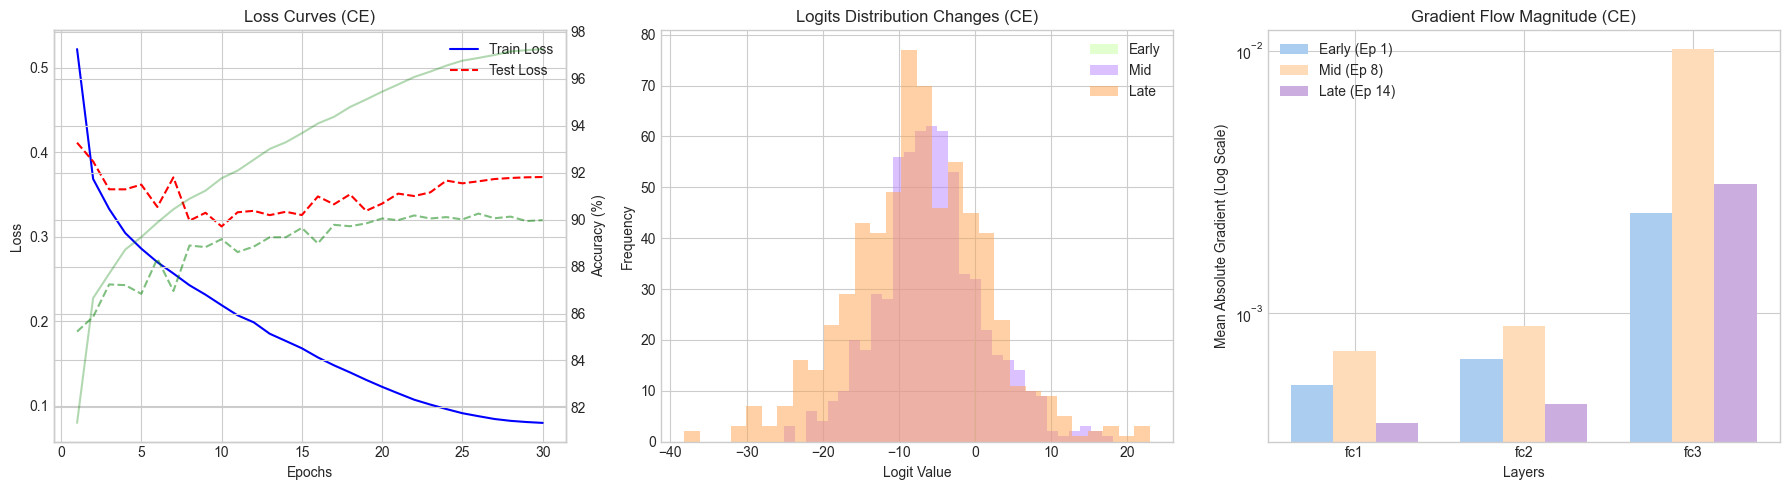


[CE 실험 결과]
--------------------------------------------------
최종 정확도 (Final Accuracy): 89.98%
Loss 최솟값 수렴 에폭 (Converged Epoch): 10 Epoch

 [실험 C: 최적화 알고리즘 비교]
--------------------------------------------------------------------------------
 Optimizer 항목    | 초기 학습률       | 최종 정확도 (%)      | 수렴 속도 (최저 Loss 에폭)   | 안정성            
--------------------------------------------------------------------------------
 Adam           | 0.001        | 89.98          % | 10                   Epoch |  0.0170        


In [121]:
def visualize_experiment_a(results):
    loss_type = results["config"]["loss_type"]
    epochs = range(1, len(results["train_loss"]) + 1)
    
    # 스타일 설정
    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(18, 5))
    

    # 그래픽 : Loss & Accuracy 학습 곡선 
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(epochs, results["train_loss"], 'b-', label='Train Loss')
    ax1.plot(epochs, results["val_loss"], 'r--', label='Test Loss')
    ax1.set_title(f'Loss Curves ({loss_type})')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(epochs, results["train_acc"], 'g-', alpha=0.3, label='Train Acc')
    ax1_twin.plot(epochs, results["val_acc"], 'g--', alpha=0.5, label='Test Acc') 
    ax1_twin.set_ylabel('Accuracy (%)')
    

    #-----------------------------------------------

    # 그래픽 : 초/중/후반 Logits 분포 
    ax2 = fig.add_subplot(1, 3, 2)
    periods = ["early", "mid", "late"]
    colors = ["#c4ffa1", "#b885ff", "#ffa34d"]
    
    for p, c in zip(periods, colors):
        data = results["logits_distribution"][p]
        if data is not None:
            # 텐서를 1차원으로 펼쳐서 전체적인 로지트 값의 범위를 히스토그램화
            ax2.hist(data.flatten(), bins=30, alpha=0.5, label=p.capitalize(), color=c)
            
    ax2.set_title(f'Logits Distribution Changes ({loss_type})')
    ax2.set_xlabel('Logit Value')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    
    #-----------------------------------------------

    # 그래픽 : 레이어별 Gradient Flow
    ax3 = fig.add_subplot(1, 3, 3)
    
    # 가로축에 배치할 레이어 이름 추출
    layers = list(results["gradient_flow"]["early"].keys()) if results["gradient_flow"]["early"] else []
    x_indexes = np.arange(len(layers))
    bar_width = 0.25
    
    if layers:
        early_grads = [results["gradient_flow"]["early"][l] for l in layers]
        mid_grads = [results["gradient_flow"]["mid"][l] for l in layers] if results["gradient_flow"]["mid"] else [0]*len(layers)
        late_grads = [results["gradient_flow"]["late"][l] for l in layers] if results["gradient_flow"]["late"] else [0]*len(layers)
        
        ax3.bar(x_indexes - bar_width, early_grads, bar_width, label='Early (Ep 1)', color='#abcdef')
        ax3.bar(x_indexes, mid_grads, bar_width, label='Mid (Ep 8)', color='#fedcba')
        ax3.bar(x_indexes + bar_width, late_grads, bar_width, label='Late (Ep 14)', color='#cbaedf')
        
        # 가독성을 위해 레이어 이름 포맷팅 (예: fc1.weight -> fc1)
        display_names = [l.split('.')[0] for l in layers]
        ax3.set_xticks(x_indexes)
        ax3.set_xticklabels(display_names)
        ax3.set_yscale('log') # Gradient 크기 차이가 극명하므로 로그 스케일
        ax3.set_title(f'Gradient Flow Magnitude ({loss_type})')
        ax3.set_xlabel('Layers')
        ax3.set_ylabel('Mean Absolute Gradient (Log Scale)')
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, 'No Gradient Data', ha='center', va='center')
        
    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------

    print("\n" + "="*50)
    print(f"[{loss_type} 실험 결과]")
    print("-"*50)
    print(f"최종 정확도 (Final Accuracy): {results['final_accuracy']:.2f}%")
    print(f"Loss 최솟값 수렴 에폭 (Converged Epoch): {results['converged_epoch']} Epoch")
    print("="*50)

    # -----------------------------------------------------------------

    print("\n" + "="*80)
    print(f" [실험 C: 최적화 알고리즘 비교]")
    print("-"*80)
    print(f" {'Optimizer 항목':<15} | {'초기 학습률':<12} | {'최종 정확도 (%)':<15} | {'수렴 속도 (최저 Loss 에폭)':<20} | {'안정성':<15}")
    print("-"*80)
    print(f" {opt_type:<14} | {lr:<12} | {results['final_accuracy']:<15.2f}% | {results['converged_epoch']:<20} Epoch | {results['stability_score']:<15}")
    print("="*80)




visualize_experiment_a(results)